In [8]:
# import sys
# !{sys.executable} -m pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 10.2 MB/s eta 0:00:00a 0:00:01
Using cached tzdata-2026.2-py2.py3-none-any.whl (349 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [seaborn]m3/4 [seaborn]

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


*Importaciones*

In [55]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import shutil
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, Conv2D, MaxPool2D, Input
from skimage.io import imread, imshow
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model


In [15]:
train_dir = "/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/kagglecatsanddogs_5340/PetImages"
d = {"dogs": 0, "cats": 1}
for dir in os.listdir(train_dir):
    path = os.path.join(train_dir, dir)
    d[dir] = len(os.listdir(path))
print(d)

{'dogs': 0, 'cats': 1, 'Cat': 12501, 'Dog': 12501}


/tmp/ipykernel_84363/2591956987.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(imread("/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/kagglecatsanddogs_5340/PetImages/Cat/1000.jpg"))


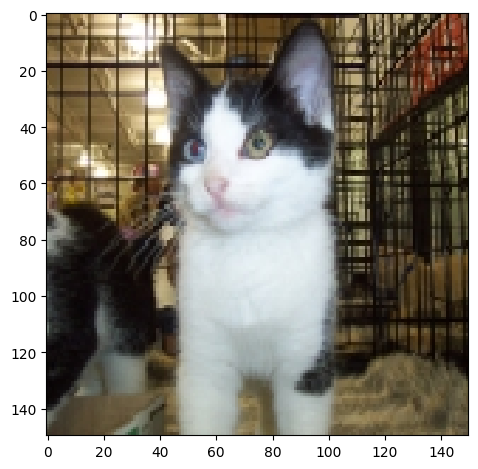

In [16]:
imshow(imread("/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/kagglecatsanddogs_5340/PetImages/Cat/1000.jpg"))

/tmp/ipykernel_84363/898593285.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(imread("/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/kagglecatsanddogs_5340/PetImages/Cat/1020.jpg"))


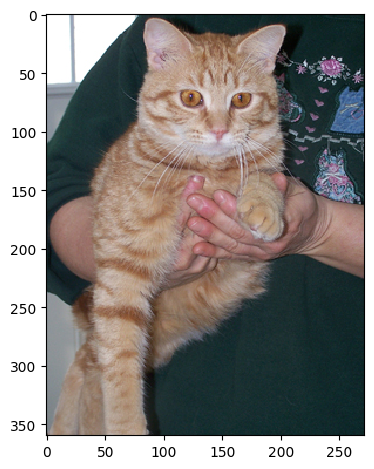

In [17]:
imshow(imread("/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/kagglecatsanddogs_5340/PetImages/Cat/1020.jpg"))

/tmp/ipykernel_84363/1123294375.py:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(imread("/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/kagglecatsanddogs_5340/PetImages/Dog/1000.jpg"))


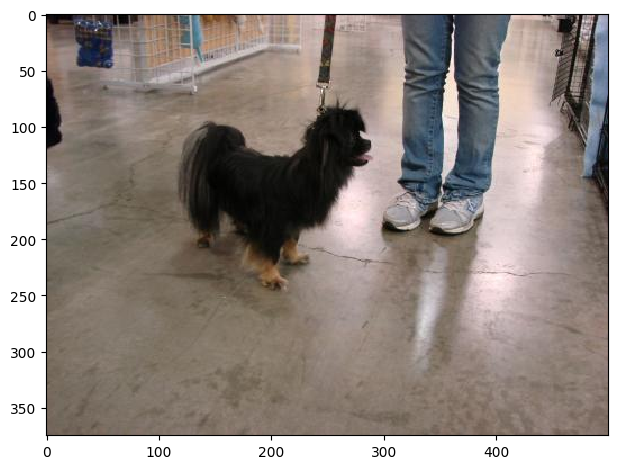

In [18]:
imshow(imread("/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/kagglecatsanddogs_5340/PetImages/Dog/1000.jpg"))

In [3]:
# es importante tener el train_dir para que cuando se quiera ejecutar solo esta linea no me lance el error
ROOT_DIR = "/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/cats_dogs"
train_dir = "/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/kagglecatsanddogs_5340/PetImages"

# se crea la estructura principal
for carpeta in ['train', 'test', 'val']:
    os.makedirs(os.path.join(ROOT_DIR, carpeta), exist_ok=True)

# se crean subcarpetas Cat y Dog
for clase in os.listdir(train_dir):
    for carpeta in ['train', 'test', 'val']:
        os.makedirs(
            os.path.join(ROOT_DIR, carpeta, clase),
            exist_ok=True
        )

# es importante no hacer os.remove(...) porque se eliminarían los archivos originales, y rompe el dataset original, como alternativa se puede usar shutil.copyfile(...) para copiar los archivos a las nuevas carpetas, y así mantener el dataset original intacto

In [4]:
# se comprueba que los datos siguen intactos
for clase in os.listdir(train_dir):
    print(clase)

for clase in os.listdir(train_dir):
    print(clase, len(os.listdir(os.path.join(train_dir, clase))))

Cat
Dog
Cat 12501
Dog 12501


In [7]:
# se va a crea la division de los datos
for clase in os.listdir(train_dir):

    source_dir = os.path.join(train_dir, clase)

    imagenes = os.listdir(source_dir)

    np.random.shuffle(imagenes)

    total = len(imagenes)

    train_size = int(total * 0.8)
    val_size = int(total * 0.1)

    train_imgs = imagenes[:train_size]
    val_imgs = imagenes[train_size:train_size + val_size]
    test_imgs = imagenes[train_size + val_size:]

    print(f"\n{clase}")
    print(f"Train: {len(train_imgs)}")
    print(f"Val:   {len(val_imgs)}")
    print(f"Test:  {len(test_imgs)}")


Cat
Train: 10000
Val:   1250
Test:  1251

Dog
Train: 10000
Val:   1250
Test:  1251


In [8]:
# copiar los archivos a las nuevas carpetas
for clase in os.listdir(train_dir):

    source_dir = os.path.join(train_dir, clase)

    imagenes = os.listdir(source_dir)

    np.random.shuffle(imagenes)

    total = len(imagenes)

    train_size = int(total * 0.8)
    val_size = int(total * 0.1)

    train_imgs = imagenes[:train_size]
    val_imgs = imagenes[train_size:train_size + val_size]
    test_imgs = imagenes[train_size + val_size:]

    print(f"\n{clase}")
    print(f"Train: {len(train_imgs)}")
    print(f"Val:   {len(val_imgs)}")
    print(f"Test:  {len(test_imgs)}")

    # Train
    for img in train_imgs:
        shutil.copy2(
            os.path.join(source_dir, img),
            os.path.join(ROOT_DIR, "train", clase, img)
        )

    # Validation
    for img in val_imgs:
        shutil.copy2(
            os.path.join(source_dir, img),
            os.path.join(ROOT_DIR, "val", clase, img)
        )

    # Test
    for img in test_imgs:
        shutil.copy2(
            os.path.join(source_dir, img),
            os.path.join(ROOT_DIR, "test", clase, img)
        )


Cat
Train: 10000
Val:   1250
Test:  1251

Dog
Train: 10000
Val:   1250
Test:  1251


In [ ]:
# comprobar que los datos se han copiado correctamente
for carpeta in ['train', 'val', 'test']:
    print(f"\n{carpeta}")

    for clase in ['Cat', 'Dog']:
        ruta = os.path.join(ROOT_DIR, carpeta, clase)
        print(clase, len(os.listdir(ruta)))


train
Cat 10000
Dog 10000

val
Cat 1250
Dog 1250

test
Cat 1251
Dog 1251


In [34]:
# .flow_from_directory - busca las carpetas de clases, detecta las imagenes, asigna etiquetas, las redimensiona a 224x224, normaliza pixeles y entrega en lotes para entrenar en CNN
traindatagenerator = ImageDataGenerator(rescale=1.0/255, rotation_range=0.3, zoom_range=0.2, horizontal_flip=True, vertical_flip=True)
train_data = traindatagenerator.flow_from_directory(directory = '/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/cats_dogs/train', class_mode = 'binary', target_size = (224, 224))

Found 19997 images belonging to 2 classes.


In [35]:
valdatagenerator = ImageDataGenerator(rescale=1.0/255)
val_data = valdatagenerator.flow_from_directory(directory = '/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/cats_dogs/val', class_mode = 'binary', target_size = (224, 224))

Found 2500 images belonging to 2 classes.


In [36]:
testdatagenerator = ImageDataGenerator(rescale=1.0/255)
test_data = testdatagenerator.flow_from_directory(directory = '/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/cats_dogs/test', class_mode = 'binary', target_size = (224, 224))

Found 2501 images belonging to 2 classes.


In [37]:
train_data.class_indices

{'Cat': 0, 'Dog': 1}

In [38]:
CLASS_ID = { j:i for i, j in train_data.class_indices.items() }

In [39]:
CLASS_ID


{0: 'Cat', 1: 'Dog'}

In [40]:
# conv2d - crea 16 filtros que recorren la imagen buscando patrones, maxpool2d - reduce la dimension de la imagen, dropout, flatten, dense 
model = Sequential ()
model.add(Conv2D(filters=16, kernel_size=(3,3), activation='relu', input_shape=(224, 224, 3)))

model.add((Conv2D(filters=16, kernel_size=(3,3), activation='relu')))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add((Conv2D(filters=32, kernel_size=(3,3), activation='relu')))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add((Conv2D(filters=64, kernel_size=(3,3), activation='relu')))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add((Conv2D(filters=128, kernel_size=(3,3), activation='relu')))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Dropout(rate = 0.4))

model.add(Flatten())

model.add(Dense(units=64, activation='relu'))
model.add(Dropout(rate = 0.4))
model.add(Dense(units=1, activation='sigmoid'))

model.summary()

/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/tf_env/lib64/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 220, 220, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 110, 110, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 108, 108, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,179,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,279,537 (4.88 MB)

 Trainable params: 1,279,537 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

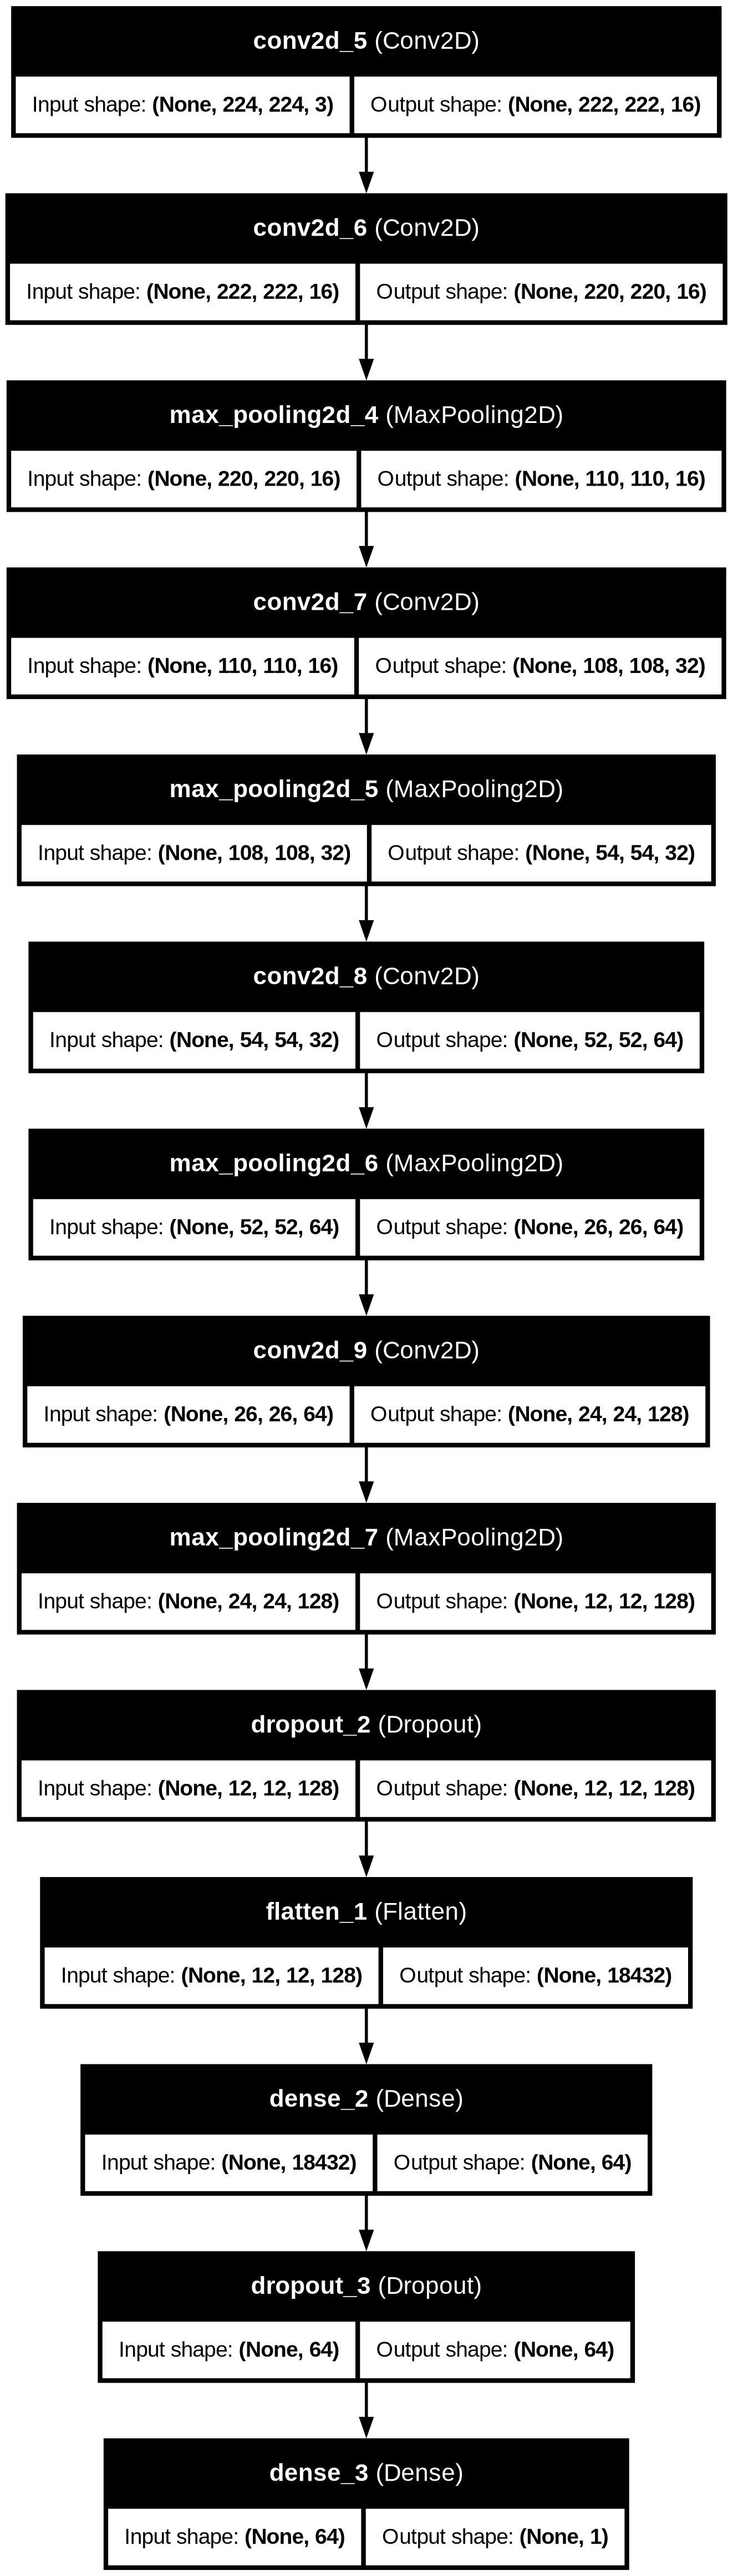

In [41]:
tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=True)

In [42]:
# binary_crossentropy - se usa para problemas de clasificación binaria, adam - es un optimizador que ajusta los pesos de la red neuronal durante el entrenamiento, accuracy - es una métrica que mide la precisión del modelo durante el entrenamiento y la evaluación
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [43]:

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# permite detener el entrenamiento cuando el modelo deje de mejorar
es = EarlyStopping(monitor='val_accuracy', min_delta=0.001, patience=5, verbose=1, mode='auto')

# guarda automaticamente el mejor modelo obtenido
mc = ModelCheckpoint(filepath='best_model.h5', monitor='val_accuracy', verbose=1, save_best_only=True, mode='auto')

# los callbacks se agurpan en lista para despues enviarlos a entrenamiento
callback = [es, mc]

In [44]:
# encontrar imagenes  corruptas
from PIL import Image
import os

ruta = "/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/datos/cats_dogs"

imagenes_danadas = []

for root, dirs, files in os.walk(ruta):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            archivo = os.path.join(root, file)

            try:
                img = Image.open(archivo)
                img.verify()
            except Exception:
                imagenes_danadas.append(archivo)

print("Imágenes dañadas:", len(imagenes_danadas))

for img in imagenes_danadas:
    print(img)

/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/tf_env/lib64/python3.10/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Imágenes dañadas: 0


In [45]:
hist = model.fit(
    train_data,
    validation_data=val_data,
    validation_steps=16,
    steps_per_epoch=32,
    epochs=30,
    verbose=1,
    callbacks=callback
)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4948 - loss: 0.7124
Epoch 1: val_accuracy improved from None to 0.58984, saving model to best_model.h5


32/32 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.4902 - loss: 0.6999 - val_accuracy: 0.5898 - val_loss: 0.6877
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 959ms/step - accuracy: 0.5302 - loss: 0.6903
Epoch 2: val_accuracy did not improve from 0.58984
32/32 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.5381 - loss: 0.6906 - val_accuracy: 0.5703 - val_loss: 0.6723
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 977ms/step - accuracy: 0.5491 - loss: 0.6829
Epoch 3: val_accuracy did not improve from 0.58984
32/32 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.5518 - loss: 0.6852 - val_accuracy: 0.5254 - val_loss: 0.6850
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 831ms/step - accuracy: 0.5581 - loss: 0.6679
Epoch 4: val_accuracy did not improve from 0.58984
32/32 ━━━━━━━━━━━━━━━━━━━━ 31s 996ms/step - accuracy: 0.5977 - loss: 0.6663 - val_accuracy: 0.5820 - val_loss: 0.6707
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 883ms/step - accuracy: 0.6244 - loss: 0.6502
Epoch 5: val_accuracy improved from 0.58

32/32 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.6182 - loss: 0.6493 - val_accuracy: 0.6309 - val_loss: 0.6363
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 746ms/step - accuracy: 0.6031 - loss: 0.6388
Epoch 6: val_accuracy did not improve from 0.63086
32/32 ━━━━━━━━━━━━━━━━━━━━ 27s 868ms/step - accuracy: 0.6230 - loss: 0.6394 - val_accuracy: 0.6211 - val_loss: 0.6342
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 816ms/step - accuracy: 0.5507 - loss: 0.6718
Epoch 7: val_accuracy did not improve from 0.63086
32/32 ━━━━━━━━━━━━━━━━━━━━ 30s 942ms/step - accuracy: 0.5312 - loss: 0.6767 - val_accuracy: 0.4922 - val_loss: 0.6670
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 891ms/step - accuracy: 0.5625 - loss: 0.6764
Epoch 8: val_accuracy did not improve from 0.63086
32/32 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.5312 - loss: 0.6876 - val_accuracy: 0.5059 - val_loss: 0.6915
Epoch 9/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 816ms/step - accuracy: 0.5153 - loss: 0.6933
Epoch 9: val_accuracy did not improve

In [46]:
# el mejor modelo se almaceno como best_model.h5
from tensorflow.keras.models import load_model 
final_model = load_model("best_model.h5")

In [ ]:
# evaluar modelo usando datos de prueba
final_model.evaluate(test_data)

# 50% → equivalente a adivinar al azar entre gato y perro.
# 63% → el modelo está aprendiendo algo, pero todavía tiene bastante margen de mejora.
# 80%–90%+ → suele considerarse un resultado bueno para este dataset con una CNN sencilla.
# 95%+ → normalmente requiere arquitecturas más avanzadas o Transfer Learning.

79/79 ━━━━━━━━━━━━━━━━━━━━ 19s 229ms/step - accuracy: 0.6329 - loss: 0.6350


[0.635001540184021, 0.6329468488693237]

# Transfer Learning

*Aprovechar el conocimiento obtenido para resolver una nueva tarea*

*VGG16*
Imagen - Convolution - Pooling - Convolution - Pooling - ... - Flatten - Capas densas - Salida

In [ ]:
# el modelo obtuvo ~~66%, VGG16 => modelo de CNN muy conocido 
from tensorflow.keras.applications.vgg16 import VGG16
vgg = VGG16(input_shape = (224, 224, 3), include_top = False, weights = 'imagenet')
vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
vgg.get_config()

{'name': 'vgg16',
 'trainable': True,
 'layers': [{'module': 'keras.layers',
   'class_name': 'InputLayer',
   'config': {'batch_shape': (None, 224, 224, 3),
    'dtype': 'float32',
    'sparse': False,
    'ragged': False,
    'name': 'input_layer_2'},
   'registered_name': None,
   'name': 'input_layer_2',
   'inbound_nodes': []},
  {'module': 'keras.layers',
   'class_name': 'Conv2D',
   'config': {'name': 'block1_conv1',
    'trainable': True,
    'dtype': {'module': 'keras',
     'class_name': 'DTypePolicy',
     'config': {'name': 'float32'},
     'registered_name': None},
    'filters': 64,
    'kernel_size': (3, 3),
    'strides': (1, 1),
    'padding': 'same',
    'data_format': 'channels_last',
    'dilation_rate': (1, 1),
    'groups': 1,
    'activation': 'relu',
    'use_bias': True,
    'kernel_initializer': {'module': 'keras.initializers',
     'class_name': 'GlorotUniform',
     'config': {'seed': None},
     'registered_name': None},
    'bias_initializer': {'module': 

In [ ]:
# congelar algunas capas ~~> evita overfifting y tiempo de entrenamiento
for layer in vgg.layers[:15]:
    layer.trainable = False

# ajuste fino, # capas posteriores si se pueden entrenar
for layer in vgg.layers[15:]:
    layer.trainable = True

In [ ]:

final_layer = vgg.layers[-1]

In [ ]:
# ultima salida
final_layer.output

<KerasTensor shape=(None, 7, 7, 512), dtype=float32, sparse=False, ragged=False, name=keras_tensor_345>

In [ ]:
# extender la capa neuronal
# imagen - VGG16 preentrenado - Nuevas capas personalizadas - Clasificación
x = Flatten() (final_layer.output)
x = Dense(512, activation='relu') (x)
x = Dropout(0.3)(x)
x = Dense(1, activation='sigmoid') (x)


In [ ]:
# unir todo en un modelo
transfer_model = Model (vgg.input, x)

In [ ]:
# resumen del modelo, 19 millones de parametros entrenados
transfer_model.summary()

Model: "functional_42"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,560,769 (105.14 MB)

 Trainable params: 19,925,505 (76.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
# baja  a 7 millones de parametros entrenados, bastante considerable
from tensorflow.keras.layers import GlobalMaxPool2D

x = GlobalMaxPool2D() (final_layer.output)
x = Dense(512, activation='relu') (x)
x = Dropout(0.3)(x)
x = Dense(1, activation='sigmoid') (x)

transfer_model = Model(vgg.input, x)

transfer_model.summary()

Model: "functional_43"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 512)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977,857 (57.14 MB)

 Trainable params: 7,342,593 (28.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
# accuaracy > 90%
transfer_model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.SGD(learning_rate=0.0001, momentum=0.9), metrics=['accuracy'])

In [ ]:
hist = transfer_model.fit(
    train_data,
    validation_data=val_data,
    validation_steps=16,
    steps_per_epoch=32,
    epochs=10,
    verbose=1,
    callbacks=callback
)

# modelo entrenado en 44.01min

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5155 - loss: 0.7576
Epoch 1: val_accuracy improved from 0.63086 to 0.68945, saving model to best_model.h5


32/32 ━━━━━━━━━━━━━━━━━━━━ 274s 9s/step - accuracy: 0.5391 - loss: 0.7423 - val_accuracy: 0.6895 - val_loss: 0.6223
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5684 - loss: 0.7044
Epoch 2: val_accuracy improved from 0.68945 to 0.71680, saving model to best_model.h5


32/32 ━━━━━━━━━━━━━━━━━━━━ 259s 8s/step - accuracy: 0.5820 - loss: 0.6955 - val_accuracy: 0.7168 - val_loss: 0.5843
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6247 - loss: 0.6356
Epoch 3: val_accuracy improved from 0.71680 to 0.82227, saving model to best_model.h5


32/32 ━━━━━━━━━━━━━━━━━━━━ 270s 9s/step - accuracy: 0.6348 - loss: 0.6326 - val_accuracy: 0.8223 - val_loss: 0.5075
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6634 - loss: 0.6061
Epoch 4: val_accuracy improved from 0.82227 to 0.83008, saving model to best_model.h5


32/32 ━━━━━━━━━━━━━━━━━━━━ 275s 9s/step - accuracy: 0.6504 - loss: 0.6162 - val_accuracy: 0.8301 - val_loss: 0.4790
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7206 - loss: 0.5595
Epoch 5: val_accuracy improved from 0.83008 to 0.84766, saving model to best_model.h5


32/32 ━━━━━━━━━━━━━━━━━━━━ 267s 8s/step - accuracy: 0.7100 - loss: 0.5642 - val_accuracy: 0.8477 - val_loss: 0.4378
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6914 - loss: 0.5598
Epoch 6: val_accuracy did not improve from 0.84766
32/32 ━━━━━━━━━━━━━━━━━━━━ 261s 8s/step - accuracy: 0.7061 - loss: 0.5480 - val_accuracy: 0.8438 - val_loss: 0.4052
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7307 - loss: 0.5240
Epoch 7: val_accuracy improved from 0.84766 to 0.85742, saving model to best_model.h5


32/32 ━━━━━━━━━━━━━━━━━━━━ 264s 8s/step - accuracy: 0.7334 - loss: 0.5177 - val_accuracy: 0.8574 - val_loss: 0.3762
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7934 - loss: 0.4659
Epoch 8: val_accuracy improved from 0.85742 to 0.87109, saving model to best_model.h5


32/32 ━━━━━━━━━━━━━━━━━━━━ 254s 8s/step - accuracy: 0.7627 - loss: 0.4875 - val_accuracy: 0.8711 - val_loss: 0.3420
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8127 - loss: 0.4150
Epoch 9: val_accuracy improved from 0.87109 to 0.87695, saving model to best_model.h5


32/32 ━━━━━━━━━━━━━━━━━━━━ 253s 8s/step - accuracy: 0.8086 - loss: 0.4316 - val_accuracy: 0.8770 - val_loss: 0.3217
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7866 - loss: 0.4441
Epoch 10: val_accuracy did not improve from 0.87695
32/32 ━━━━━━━━━━━━━━━━━━━━ 261s 8s/step - accuracy: 0.7900 - loss: 0.4433 - val_accuracy: 0.8770 - val_loss: 0.3086


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
Valor sigmoid: 0.5530431
Predicción del modelo: Dog
Probabilidad de perro: 0.5530
Probabilidad de gato : 0.4470


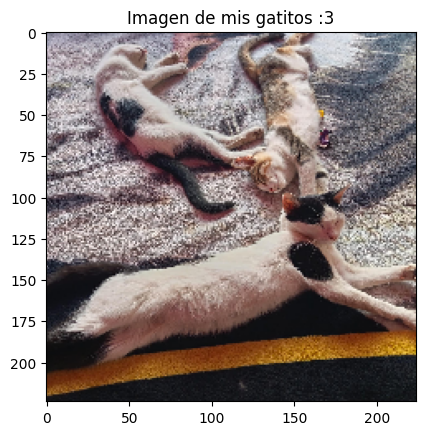

In [74]:
best_model = load_model("best_model.h5")
from tensorflow.keras.utils import load_img, img_to_array

ruta = "/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/img/animals/cats.jpeg"

pil = load_img(ruta, target_size=(224, 224))
image = img_to_array(pil)
image = image/255.0

plt.imshow(image)
plt.title("Imagen de mis gatitos :3")
plt.show

# Agregar dimensión batch
image = np.expand_dims(image, axis=0)

# Predicción
pred = best_model.predict(image)

print("Valor sigmoid:", pred[0][0])

# Clasificación binaria
class_id = int(pred[0][0] > 0.5)

CLASS_ID = {
    0: "Cat",
    1: "Dog"
}

print(f"Predicción del modelo: {CLASS_ID[class_id]}")
pred = pred[0][0]

print(f"Probabilidad de perro: {pred:.4f}")
print(f"Probabilidad de gato : {1-pred:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 876ms/step
Valor sigmoid: 0.42722788
Predicción del modelo: Cat
Probabilidad de perro: 0.4272
Probabilidad de gato : 0.5728


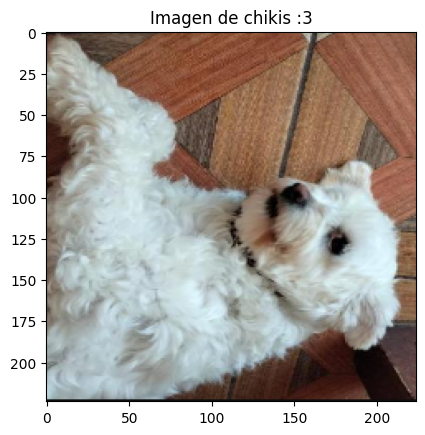

In [73]:
best_model = load_model("best_model.h5")
from tensorflow.keras.utils import load_img, img_to_array

ruta = "/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/img/animals/chikis.png"

pil = load_img(ruta, target_size=(224, 224))
image = img_to_array(pil)
image = image/255.0

plt.imshow(image)
plt.title("Imagen de chikis :3")
plt.show

# Agregar dimensión batch
image = np.expand_dims(image, axis=0)

# Predicción
pred = best_model.predict(image)

print("Valor sigmoid:", pred[0][0])

# Clasificación binaria
class_id = int(pred[0][0] > 0.5)

CLASS_ID = {
    0: "Cat",
    1: "Dog"
}

print(f"Predicción del modelo: {CLASS_ID[class_id]}")
pred = pred[0][0]

print(f"Probabilidad de perro: {pred:.4f}")
print(f"Probabilidad de gato : {1-pred:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 799ms/step
Valor sigmoid: 0.809196
Predicción del modelo: Dog
Probabilidad de perro: 0.8092
Probabilidad de gato : 0.1908


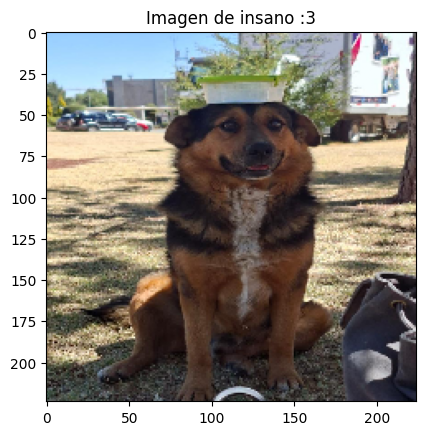

In [75]:
best_model = load_model("best_model.h5")
from tensorflow.keras.utils import load_img, img_to_array

ruta = "/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/img/animals/insane.jpeg"

pil = load_img(ruta, target_size=(224, 224))
image = img_to_array(pil)
image = image/255.0

plt.imshow(image)
plt.title("Imagen de insano :3")
plt.show

# Agregar dimensión batch
image = np.expand_dims(image, axis=0)

# Predicción
pred = best_model.predict(image)

print("Valor sigmoid:", pred[0][0])

# Clasificación binaria
class_id = int(pred[0][0] > 0.5)

CLASS_ID = {
    0: "Cat",
    1: "Dog"
}

print(f"Predicción del modelo: {CLASS_ID[class_id]}")
pred = pred[0][0]

print(f"Probabilidad de perro: {pred:.4f}")
print(f"Probabilidad de gato : {1-pred:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 798ms/step
Valor sigmoid: 0.27294984
Predicción del modelo: Cat
Probabilidad de perro: 0.2729
Probabilidad de gato : 0.7271


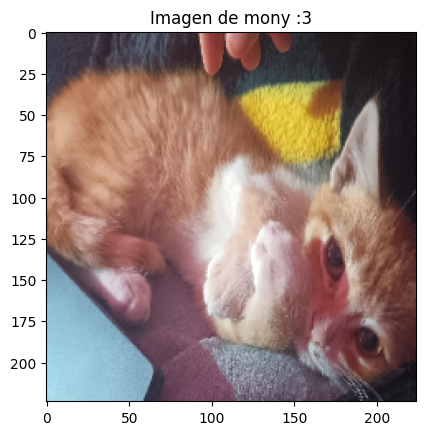

In [76]:
best_model = load_model("best_model.h5")
from tensorflow.keras.utils import load_img, img_to_array

ruta = "/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/img/animals/mony.jpeg"

pil = load_img(ruta, target_size=(224, 224))
image = img_to_array(pil)
image = image/255.0

plt.imshow(image)
plt.title("Imagen de mony :3")
plt.show

# Agregar dimensión batch
image = np.expand_dims(image, axis=0)

# Predicción
pred = best_model.predict(image)

print("Valor sigmoid:", pred[0][0])

# Clasificación binaria
class_id = int(pred[0][0] > 0.5)

CLASS_ID = {
    0: "Cat",
    1: "Dog"
}

print(f"Predicción del modelo: {CLASS_ID[class_id]}")
pred = pred[0][0]

print(f"Probabilidad de perro: {pred:.4f}")
print(f"Probabilidad de gato : {1-pred:.4f}")

In [ ]:
# guardar el modelo
transfer_model.save("best_model.h5")

In [ ]:
# guardar modelo version moderna
transfer_model.save("best_model.keras")